Importing Libraries

In [ ]:
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

Loading dataset

In [ ]:
# Load the dataset
dataset_download_url = "https://www.kaggle.com/api/v1/datasets/download/ziya07/plant-health-data"

zip_path = "plant_health_data.zip"
urllib.request.urlretrieve(dataset_download_url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("plant_health_data")
plant_health_df = pd.read_csv('/content/plant_health_data/plant_health_data.csv')


Data Preprocessing

In [ ]:
# Encode plant health status
plant_health_status_map = {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}
plant_health_df['Health_Status_Encoded'] = plant_health_df['Plant_Health_Status'].map(plant_health_status_map)

In [ ]:
# Define features and target
X = plant_health_df.drop(columns=['Health_Status_Encoded', "Plant_Health_Status", "Timestamp", 'Plant_ID'])  # Features
y = plant_health_df['Health_Status_Encoded']  # Target

In [ ]:
X, y

(      Soil_Moisture  Ambient_Temperature  Soil_Temperature   Humidity  \
 0         27.521109            22.240245         21.900435  55.291904   
 1         14.835566            21.706763         18.680892  63.949181   
 2         17.086362            21.180946         15.392939  67.837956   
 3         15.336156            22.593302         22.778394  58.190811   
 4         39.822216            28.929001         18.100937  63.772036   
 ...             ...                  ...               ...        ...   
 1195      29.665780            27.605285         15.381699  54.668196   
 1196      15.490782            22.108112         15.221033  61.243143   
 1197      23.495723            21.680240         15.499764  40.693671   
 1198      30.971675            23.019488         21.934918  41.387107   
 1199      24.406357            25.724605         23.358573  47.505394   
 
       Light_Intensity   Soil_pH  Nitrogen_Level  Phosphorus_Level  \
 0          556.172805  5.581955       1

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training and Evaluating



In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True),  # probability=True needed for AUC
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}



 Model: Logistic Regression
 Accuracy: 0.7500
 F1 Score: 0.7492
📈 AUC Score: 0.9026

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.80      0.78      0.79        60
Moderate Stress       0.64      0.62      0.63        80
    High Stress       0.81      0.83      0.82       100

       accuracy                           0.75       240
      macro avg       0.75      0.75      0.75       240
   weighted avg       0.75      0.75      0.75       240



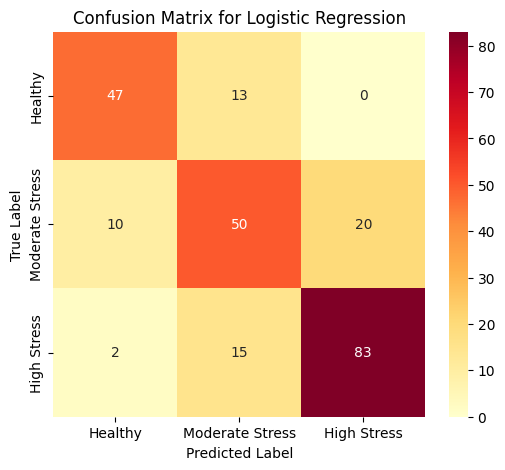


 Model: Naive Bayes
 Accuracy: 0.7833
 F1 Score: 0.7850
📈 AUC Score: 0.9302

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.79      0.80      0.79        60
Moderate Stress       0.70      0.78      0.73        80
    High Stress       0.87      0.78      0.82       100

       accuracy                           0.78       240
      macro avg       0.78      0.79      0.78       240
   weighted avg       0.79      0.78      0.79       240



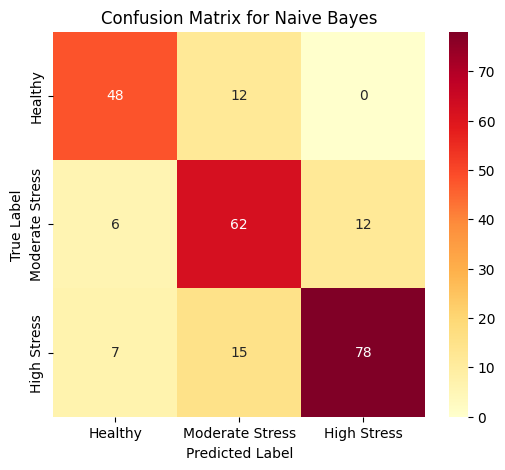


 Model: Support Vector Machine
 Accuracy: 0.7958
 F1 Score: 0.7962
📈 AUC Score: 0.9440

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.84      0.80      0.82        60
Moderate Stress       0.70      0.71      0.70        80
    High Stress       0.85      0.86      0.86       100

       accuracy                           0.80       240
      macro avg       0.80      0.79      0.79       240
   weighted avg       0.80      0.80      0.80       240



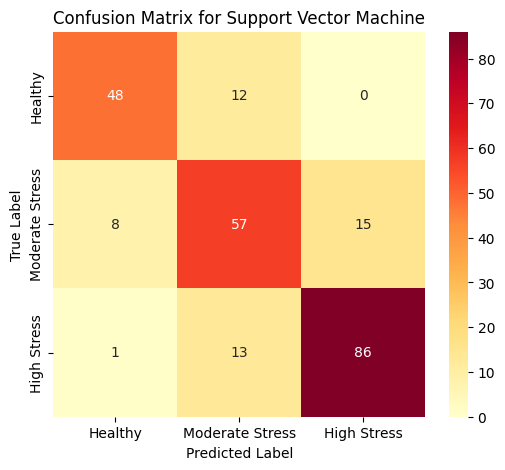


 Model: K-Nearest Neighbors
 Accuracy: 0.6417
 F1 Score: 0.6516
📈 AUC Score: 0.8100

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.57      0.65      0.61        60
Moderate Stress       0.49      0.57      0.53        80
    High Stress       0.88      0.69      0.78       100

       accuracy                           0.64       240
      macro avg       0.65      0.64      0.64       240
   weighted avg       0.68      0.64      0.65       240



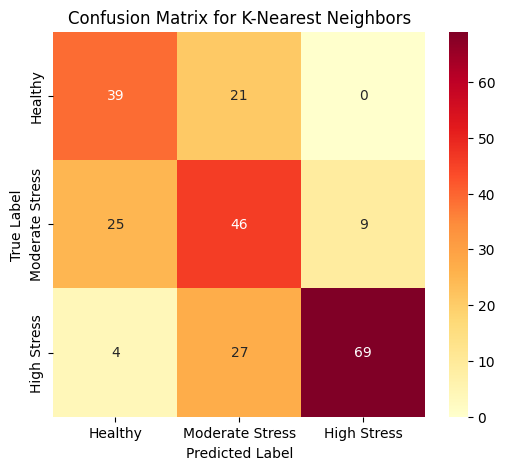


 Model: Decision Tree
 Accuracy: 0.9917
 F1 Score: 0.9917
📈 AUC Score: 0.9935

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



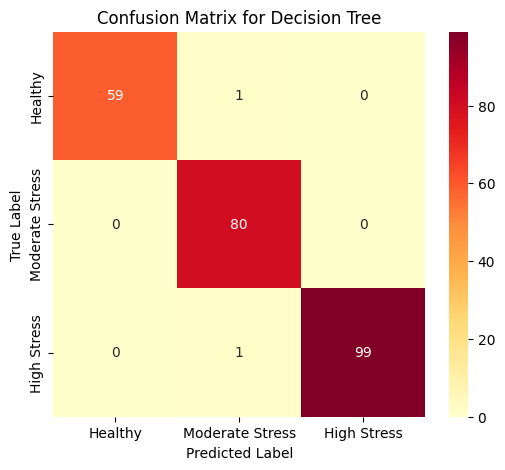


 Model: Random Forest
 Accuracy: 0.9875
 F1 Score: 0.9875
📈 AUC Score: 0.9999

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



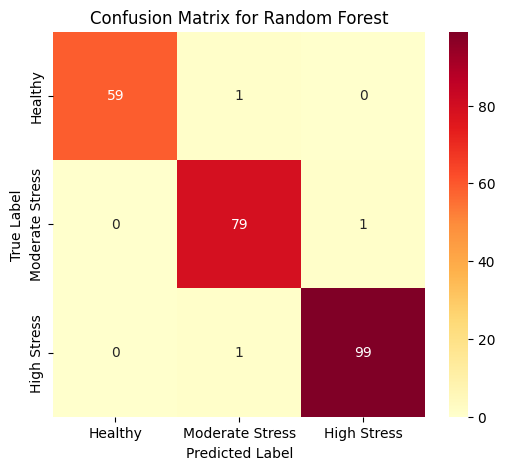


 Model: Gradient Boosting
 Accuracy: 0.9875
 F1 Score: 0.9875
📈 AUC Score: 0.9940

🔍 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



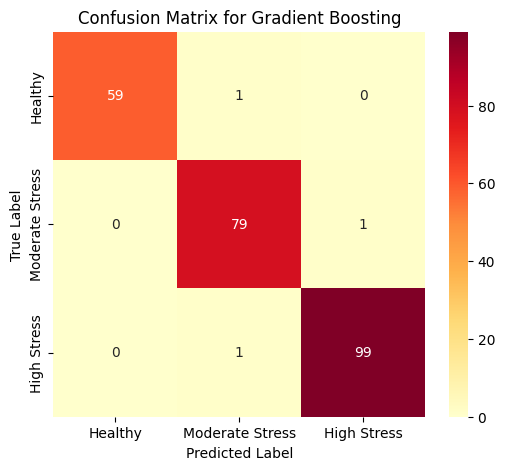

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

# Storage for model evaluation results
model_metrics = []

# Train, predict, and evaluate each model
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # AUC (if possible)
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = None

    # Classification report and confusion matrix (specific per model)
    class_report = classification_report(y_test, y_pred, target_names=['Healthy', 'Moderate Stress', 'High Stress'])
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Store all metrics
    model_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "AUC": auc,
        "Classification Report": class_report,
        "Confusion Matrix": conf_matrix
    })

# Show all results
for res in model_metrics:
    print(f"\n Model: {res['Model']}")
    print(f" Accuracy: {res['Accuracy']:.4f}")
    print(f" F1 Score: {res['F1 Score']:.4f}")
    if res["AUC"] is not None:
        print(f"📈 AUC Score: {res['AUC']:.4f}")

    print("\n🔍 Classification Report:")
    print(res["Classification Report"])

    # Visualize Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(res["Confusion Matrix"], annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['Healthy', 'Moderate Stress', 'High Stress'],
                yticklabels=['Healthy', 'Moderate Stress', 'High Stress'])
    plt.title(f'Confusion Matrix for {res["Model"]}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


In [ ]:
# Define simple weights for each metric
weight_auc = 0.4
weight_f1 = 0.4
weight_acc = 0.2

# Calculate composite score for each model
for model in model_metrics:
    auc = model["AUC"] if model["AUC"] is not None else 0
    f1 = model["F1 Score"]
    acc = model["Accuracy"]

    # Weighted sum
    model["Score"] = (
        weight_auc * auc +
        weight_f1 * f1 +
        weight_acc * acc
    )

# Rank models by score
ranked_models = sorted(model_metrics, key=lambda m: m["Score"], reverse=True)

# Display the ranked models
print("\n Ranked Models:")
for i, m in enumerate(ranked_models, start=1):
    print(f"{i}. {m['Model']} - Score: {m['Score']:.3f}")

# Best model
print(f"\n Best Model: {ranked_models[0]['Model']} with Score: {ranked_models[0]['Score']:.3f}")



 Ranked Models:
1. Random Forest - Score: 0.992
2. Decision Tree - Score: 0.992
3. Gradient Boosting - Score: 0.990
4. Support Vector Machine - Score: 0.855
5. Naive Bayes - Score: 0.843
6. Logistic Regression - Score: 0.811
7. K-Nearest Neighbors - Score: 0.713

 Best Model: Random Forest with Score: 0.992
